# CUAD: Exploratory Data Analysis

**Stage 2 of the Accenture contract review challenge.**

Goal of this notebook: perform an exploratory data analysis on the pre-cleaned parquet splits (contracts, spans, grid) generated in Stage 1. This notebook examines document character length distributions, clause span sizes, spatial positioning, multi-label relationships, data quality flags, and baseline missing-clause frequencies to establish baseline data properties.

Input Tables (from `src.cuad_data`):

| file | one row per | used for |
|---|---|---|
| `contracts.parquet` | contract | Document character length distributions |
| `spans.parquet` | annotated clause span | Span length, spatial location (`rel_position`), redaction prevalence |
| `grid.parquet` | contract x category | Class imbalance per split, co-occurrence, missing-clause frequency |

---
## 0. Setup

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

from src.cuad_data import load_split, PRIORITY_CATEGORIES

---
## 1. Load the Parquet Splits

We load the official `train` (408 contracts) and `test` (102 contracts) splits using `load_split` from `src.cuad_data`.

In [ ]:
train = load_split("train")
test = load_split("test")

print(f"Train: {len(train.contracts)} contracts | {len(train.spans)} spans | {len(train.grid)} grid rows")
print(f"Test:  {len(test.contracts)} contracts  | {len(test.spans)} spans  | {len(test.grid)} grid rows")

Train: 408 contracts | 11180 spans | 16728 grid rows
Test:  102 contracts  | 2643 spans  | 4080 grid rows


---
## 2. Contract Length Distribution

Document character length (`n_chars`) varies substantially across the dataset. We inspect the character counts using `train.contracts`.

In [ ]:
display(train.contracts["n_chars"].describe().round(0))

count       408.0
mean      53992.0
std       55985.0
min        1081.0
25%       16570.0
50%       35960.0
75%       68440.0
max      338211.0
Name: n_chars, dtype: float64

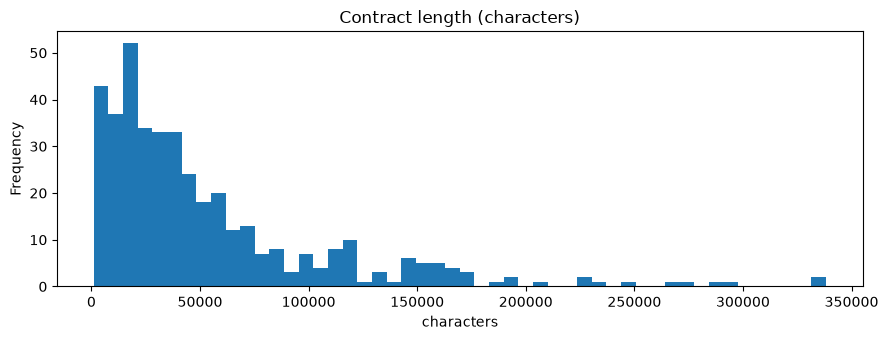

In [ ]:
ax = train.contracts["n_chars"].plot.hist(
    bins=50, 
    figsize=(9, 3.5), 
    title="Contract length (characters)"
)
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()


**Findings:**
- The histogram shows a heavy right tail: while 50% of contracts are under ~33,000 characters, the longest documents exceed 300,000 characters.

---
## 3. Clause Span Length by Category

Clause span character lengths (`n_chars_span`) vary depending on annotation type. We group `train.spans` by `category` and compute character length statistics.

In [ ]:
span_length_stats = (
    train.spans.groupby("category")["n_chars_span"]
    .agg(["count", "median", "mean", "max"])
    .round(0)
    .sort_values("median", ascending=False)
)

print("--- Top 15 Categories by Median Span Length (Train) ---")
display(span_length_stats.head(15))

--- Top 15 Categories by Median Span Length (Train) ---


,count,median,mean,max
category,,,,
Affiliate License-Licensee,88,505.0,566.0,2457
Affiliate License-Licensor,49,489.0,601.0,2457
Irrevocable Or Perpetual License,142,484.0,540.0,2457
Uncapped Liability,151,427.0,448.0,1624
Post-Termination Services,368,378.0,465.0,1778
Competitive Restriction Exception,98,374.0,469.0,2820
Most Favored Nation,35,371.0,452.0,1136
Non-Transferable License,255,361.0,435.0,2246
License Grant,642,358.0,431.0,2457


**Findings:**
- `Affiliate License-Licensee` has the highest median span length (**505.0 characters**; count: 88, mean: 566.0, max: 2,457), followed by `Affiliate License-Licensor` (**489.0 characters**; count: 49, mean: 601.0, max: 2,457) and `Irrevocable Or Perpetual License` (**484.0 characters**; count: 142, mean: 540.0, max: 2,457)
- `Uncapped Liability` has a median span length of **427.0 characters** (count: 151, mean: 448.0, max: 1,624), while `Cap On Liability` has a median span length of **312.0 characters** (count: 554, mean: 380.0, max: 1,887)
- `License Grant` has the largest span count in the top 15 list (**642 spans**; median: 358.0, mean: 431.0, max: 2,457), followed by `Cap On Liability` (**554 spans**)

---
## 4. Spatial Location of Clauses (`rel_position`)

`spans.parquet` includes `rel_position`, calculated as $\frac{\text{span\_start}}{\text{contract\_n\_chars}}$ ($0.0 = \text{start}$, $1.0 = \text{end}$). We examine the relative placement of the 10 advisor-priority categories across contracts.

C:\Users\SEN\AppData\Local\Temp\ipykernel_18668\2745887653.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


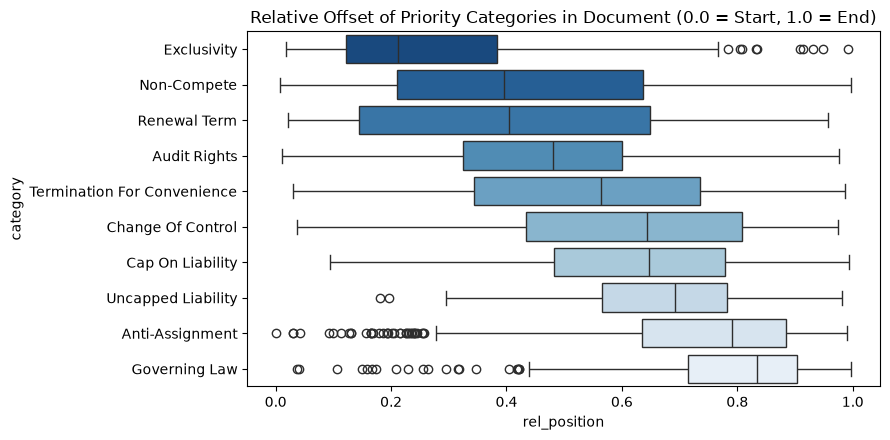

In [ ]:
priority_spans = train.priority().copy()

pos_order = (
    priority_spans.groupby("category")["rel_position"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(9, 4.5))
sns.boxplot(
    data=priority_spans,
    x="rel_position",
    y="category",
    order=pos_order,
    palette="Blues_r"
)
plt.title("Relative Offset of Priority Categories in Document (0.0 = Start, 1.0 = End)")
plt.xlabel("rel_position")
plt.ylabel("category")
plt.tight_layout()
plt.show()

**Findings:**
- `Governing Law` has the highest median relative offset (~0.83) and the narrowest IQR (~0.70 to ~0.90). While the core 75% of clauses lie in the final 30% of the document, a scatter of early outliers appears between 0 and 0.43.
- `Exclusivity` is the earliest-positioned priority category, with a median offset of ~0.20 and an IQR between ~0.1 and ~0.38.
- `Audit Rights` centers mid-document (median ~0.50, IQR ~0.35 to ~0.60)
- `Non-Compete` (median ~0.40) and `Renewal Term` (median ~0.40) display wide IQRs spanning from ~0.15–0.20 to ~0.65 and full whisker ranges from 0.0 to 1.0, indicating variable placement across agreements.

---
## 5. Class Imbalance, per Split

`grid.parquet` contains every contract $\times$ category combination, including zero counts. We aggregate `grid` to compute presence rates (`train_pct` vs `test_pct`) and measure the distribution gap (`pct_gap`).

In [ ]:
def coverage_of(split):
    return (
        split.grid.groupby("category")["has_clause"]
        .agg(**{f"{split.name}_n": "sum", f"{split.name}_pct": "mean"})
        .assign(**{f"{split.name}_pct": lambda d: (d[f"{split.name}_pct"] * 100).round(1)})
    )

cov = coverage_of(train).join(coverage_of(test)).sort_values("train_n", ascending=False)
cov["pct_gap"] = (cov["train_pct"] - cov["test_pct"]).abs()

print("--- Top 10 Categories by Train/Test Distribution Gap ---")
display(cov.sort_values("pct_gap", ascending=False).head(10)[["train_pct", "test_pct", "pct_gap"]])

--- Top 10 Categories by Train/Test Distribution Gap ---


,train_pct,test_pct,pct_gap
category,,,
Cap On Liability,56.6,43.1,13.5
Uncapped Liability,24.0,12.7,11.3
Renewal Term,36.8,25.5,11.3
Effective Date,78.4,68.6,9.8
Termination For Convenience,37.7,28.4,9.3
Post-Termination Services,37.5,28.4,9.1
Notice Period To Terminate Renewal,23.3,15.7,7.6
Non-Transferable License,28.4,21.6,6.8
Warranty Duration,15.9,9.8,6.1


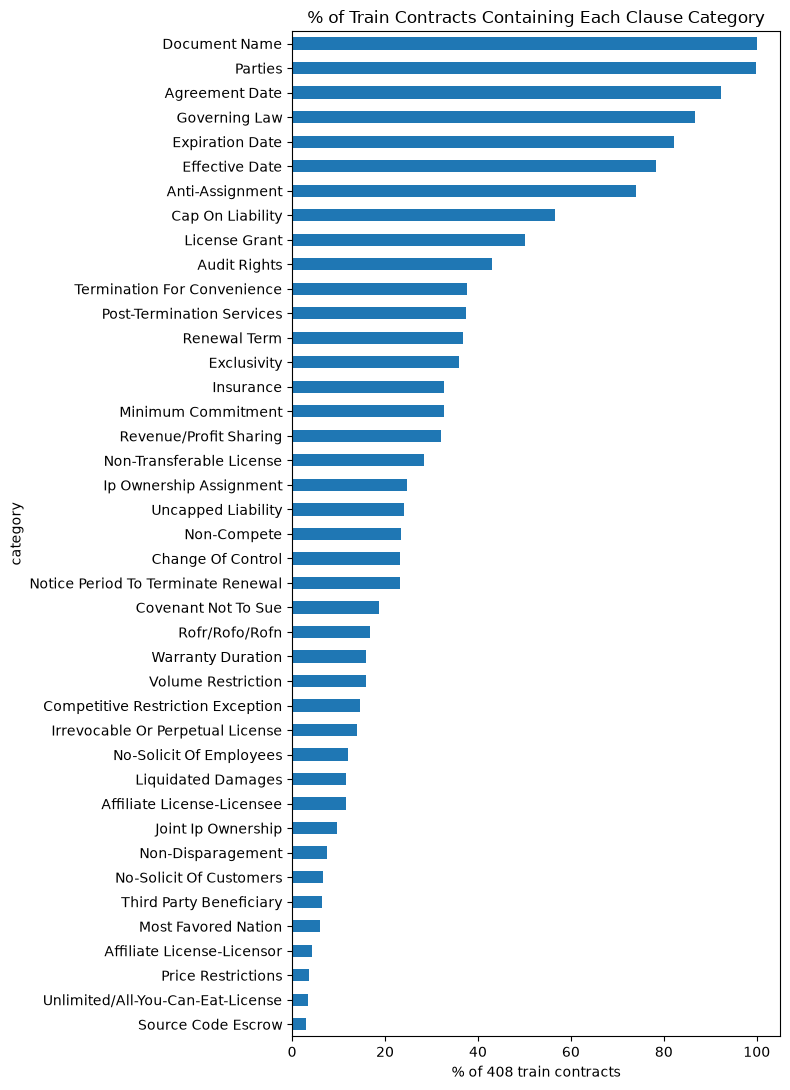

In [ ]:
ax = cov["train_pct"].sort_values().plot.barh(
    figsize=(8, 11), 
    title="% of Train Contracts Containing Each Clause Category"
)
ax.set_xlabel("% of 408 train contracts")
plt.tight_layout()
plt.show()

**Findings:**
- `Cap On Liability` has the largest presence rate gap (13.5%) between splits (56.6% train vs. 43.1% test), followed by `Uncapped Liability` and `Renewal Term`, both with a gap of 11.3%
- Across 408 training contracts, metadata categories like `Document Name` (100.0%) and `Parties` (99.8%) occur in almost all contracts, while substantive risk terms are present in only 25% to 55% of training contracts


---
## 6. Multi-Label Category Co-occurrence

A single contract passage can carry multiple category annotations simultaneously. We pivot `train.grid` across the 10 priority categories to construct a contract-level co-occurrence matrix.

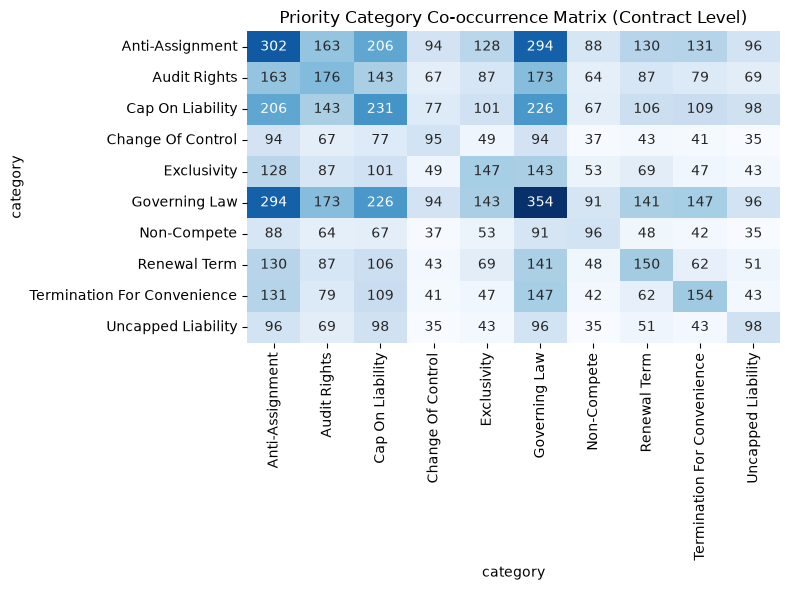

In [ ]:
priority_grid = train.grid[train.grid["category"].isin(PRIORITY_CATEGORIES)].copy()
pivot_grid = priority_grid.pivot(index="contract", columns="category", values="has_clause").astype(int)

co_matrix = pivot_grid.T.dot(pivot_grid)

plt.figure(figsize=(8, 6))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Priority Category Co-occurrence Matrix (Contract Level)")
plt.tight_layout()
plt.show()

**Highest Co-occurring Priority Pairs**:
- `Governing Law` & `Anti-Assignment`: 294 contracts
- `Governing Law` & `Cap On Liability`: 226 contracts
- `Anti-Assignment` & `Cap On Liability`: 206 contracts
- `Governing Law` & `Audit Rights`: 173 contracts
- `Anti-Assignment` & `Audit Rights`: 163 contracts
- `Governing Law` & `Termination For Convenience`: 147 contracts

In [ ]:
clause_counts_per_doc = pivot_grid.sum(axis=1)
print("--- Number of Priority Categories Present per Contract ---")
display(clause_counts_per_doc.describe().round(2))

--- Number of Priority Categories Present per Contract ---


count    408.00
mean       4.42
std        2.44
min        0.00
25%        3.00
50%        5.00
75%        6.00
max       10.00
dtype: float64

---
## 7. Clause Multiplicity (Multiple Spans per Contract)

We analyze how frequently a single contract contains multiple distinct annotations for the same category.

In [ ]:
spans_per_doc = (
    train.spans[train.spans["category"].isin(PRIORITY_CATEGORIES)]
    .groupby(["contract", "category"])
    .size()
    .reset_index(name="span_count")
)

multi_span_summary = (
    spans_per_doc.groupby("category")["span_count"]
    .agg(
        total_contracts_present="count",
        max_spans_in_one_doc="max",
        mean_spans_when_present="mean",
        pct_docs_with_multiple=lambda s: (s > 1).mean() * 100
    )
    .round(1)
    .sort_values("pct_docs_with_multiple", ascending=False)
)

print("--- Clause Multiplicity Summary (Priority Categories) ---")
display(multi_span_summary)


--- Clause Multiplicity Summary (Priority Categories) ---


,total_contracts_present,max_spans_in_one_doc,mean_spans_when_present,pct_docs_with_multiple
category,,,,
Audit Rights,176,19,3.1,63.6
Change Of Control,95,6,2.0,60.0
Cap On Liability,231,16,2.4,57.6
Exclusivity,147,12,2.3,56.5
Non-Compete,96,12,2.1,51.0
Anti-Assignment,302,7,1.7,43.0
Uncapped Liability,98,5,1.5,34.7
Termination For Convenience,154,4,1.3,26.6
Renewal Term,150,5,1.2,14.7


C:\Users\SEN\AppData\Local\Temp\ipykernel_18668\3844759365.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


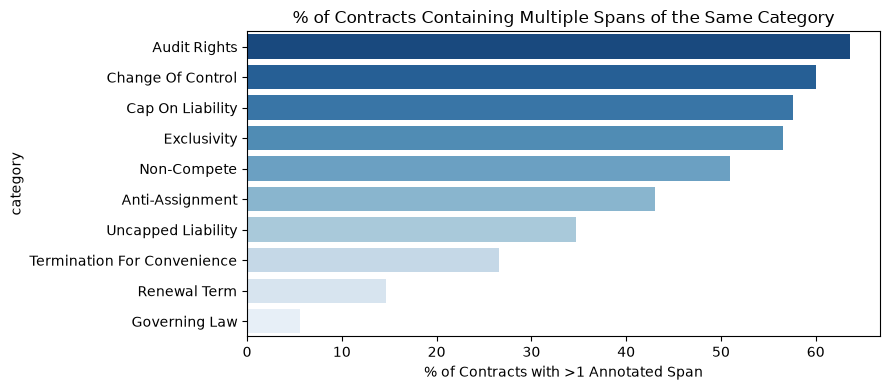

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=multi_span_summary.reset_index(),
    x="pct_docs_with_multiple",
    y="category",
    palette="Blues_r",
    ax=ax
)
ax.set_title("% of Contracts Containing Multiple Spans of the Same Category")
ax.set_xlabel("% of Contracts with >1 Annotated Span")
plt.tight_layout()
plt.show()

**Findings:**
- When present, `Audit Rights` has the highest average multiplicity at 3.1 annotated spans per contract (up to a maximum of 19 spans in a single document; ~64% of contracts containing Audit Rights have >1 span)
- `Cap On Liability` averages 2.4 spans per contract (max 16 spans; ~58% of contracts have >1 span)
- `Exclusivity` averages 2.3 spans (max 12 spans; ~57% with >1 span)
- `Governing Law` exhibits the lowest multiplicity, averaging 1.1 spans per contract (max 2 spans) with only ~6% of contracts containing more than 1 span


---
## 8. Contract Length vs. Priority Clause Density

We evaluate whether document character length correlates directly with the number of priority clauses present.

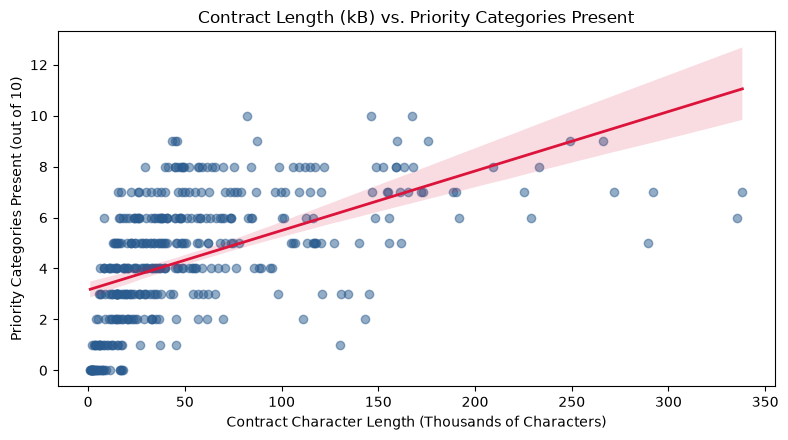

In [ ]:
doc_density = train.contracts.merge(
    pivot_grid.sum(axis=1).rename("priority_clause_count"),
    left_on="contract",
    right_index=True
)
doc_density["length_kb"] = doc_density["n_chars"] / 1000.0

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.regplot(
    data=doc_density,
    x="length_kb",
    y="priority_clause_count",
    scatter_kws={"alpha": 0.5, "color": "#2b5c8f"},
    line_kws={"color": "crimson", "linewidth": 2},
    ax=ax
)
ax.set_title("Contract Length (kB) vs. Priority Categories Present")
ax.set_xlabel("Contract Character Length (Thousands of Characters)")
ax.set_ylabel("Priority Categories Present (out of 10)")
plt.tight_layout()
plt.show()


In [ ]:
corr = doc_density["n_chars"].corr(doc_density["priority_clause_count"])
print(f"Pearson Correlation (n_chars vs priority_clause_count): {corr:.3f}")

Pearson Correlation (n_chars vs priority_clause_count): 0.536


**Findings:**
- There is a moderate positive linear correlation (r = 0.536) between contract character length (`n_chars`) and the number of priority categories present (`priority_clause_count` out of 10)
- While longer contracts generally contain more priority categories, there is high variance across length buckets: several shorter contracts (<50,000 characters) contain 8–9 priority categories, whereas some long contracts (>150,000 characters) contain only 3–4 priority terms

---
## 9. Data Quality Flags: SEC Redactions & Short Spans

`spans.parquet` includes quality flags (`has_redaction`, `is_very_short`, `whitespace_ratio`). We measure the prevalence of SEC confidential treatment redactions (`[***]`) and very short spans (<15 characters) across priority categories.

In [ ]:
redaction_stats = (
    train.priority()
    .groupby("category")["has_redaction"]
    .agg(total_spans="count", redacted_spans="sum")
    .assign(redacted_pct=lambda d: (d["redacted_spans"] / d["total_spans"] * 100).round(1))
)

short_stats = (
    train.priority()
    .groupby("category")["is_very_short"]
    .agg(short_spans="sum")
    .join(redaction_stats["total_spans"])
    .assign(short_pct=lambda d: (d["short_spans"] / d["total_spans"] * 100).round(1))
)

quality_summary = redaction_stats.join(short_stats[["short_spans", "short_pct"]]).sort_values("redacted_pct", ascending=False)

print("--- Data Quality Flags Across Priority Categories ---")
display(quality_summary)

--- Data Quality Flags Across Priority Categories ---


,total_spans,redacted_spans,redacted_pct,short_spans,short_pct
category,,,,,
Uncapped Liability,151,21,13.9,0,0.0
Change Of Control,191,19,9.9,0,0.0
Audit Rights,538,44,8.2,1,0.2
Cap On Liability,554,39,7.0,0,0.0
Termination For Convenience,205,13,6.3,0,0.0
Non-Compete,200,10,5.0,1,0.5
Renewal Term,179,7,3.9,1,0.6
Exclusivity,332,10,3.0,1,0.3
Anti-Assignment,517,7,1.4,1,0.2


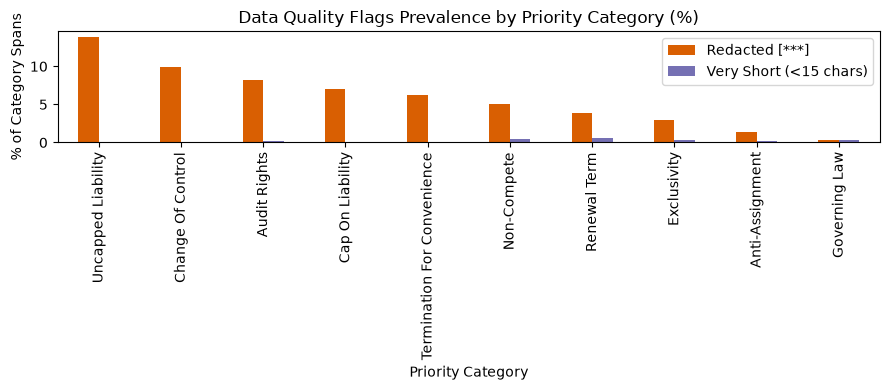

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
quality_summary[["redacted_pct", "short_pct"]].plot.bar(ax=ax, color=["#d95f02", "#7570b3"])
ax.set_title("Data Quality Flags Prevalence by Priority Category (%)")
ax.set_ylabel("% of Category Spans")
ax.set_xlabel("Priority Category")
plt.legend(["Redacted [***]", "Very Short (<15 chars)"])
plt.tight_layout()
plt.show()

**Findings:**
- SEC confidential treatment blackouts (`[***]`) are heavily concentrated in substantive liability and compliance categories: `Uncapped Liability` has the highest percentage of redacted spans at 13.9%, followed by `Change Of Control` at 9.9% and `Audit Rights` at 8.2%.
- `Governing Law` has the lowest redaction frequency with 1 redacted span out of 374 spans (0.3%)
- Spans under 15 characters (`is_very_short`) account for <0.6% of spans across all priority categories (e.g., 1 span in `Renewal Term`, 1 in `Non-Compete`, 1 in `Audit Rights`)

---
## 10. Missing-Clause Frequency

The absence of a protective clause (like a liability cap or audit right) is a primary risk indicator. Using `train.grid` where `has_clause == False`, we compute missing-clause frequencies for high-risk categories.

In [ ]:
risk_grid = train.grid[train.grid["category"].isin(PRIORITY_CATEGORIES)].copy()

triage_summary = (
    risk_grid.groupby("contract")["has_clause"]
    .agg(
        present_count="sum",
        missing_count=lambda x: len(x) - x.sum()
    )
)

print("--- Missing High-Risk Clauses per Contract (Train Set) ---")
display(triage_summary["missing_count"].value_counts().sort_index().to_frame("contract_count"))

--- Missing High-Risk Clauses per Contract (Train Set) ---


,contract_count
missing_count,
0,3
1,8
2,35
3,42
4,58
5,59
6,61
7,50
8,32


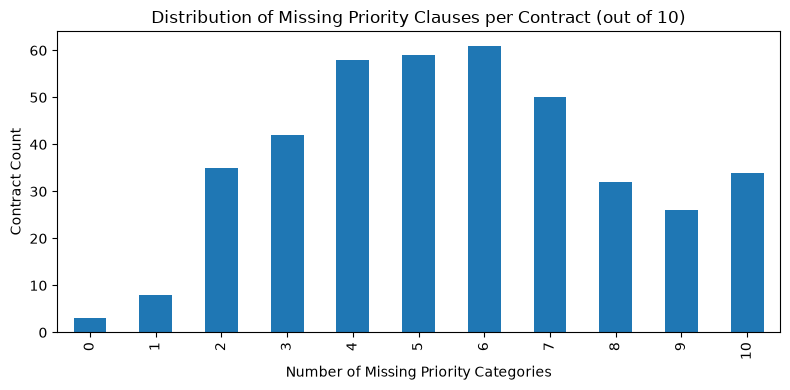

--- Contract Priority Clause Coverage Summary ---


count    408.00
mean       5.58
std        2.44
min        0.00
25%        4.00
50%        5.00
75%        7.00
max       10.00
Name: missing_count, dtype: float64

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
triage_summary["missing_count"].value_counts().sort_index().plot.bar(ax=ax)
ax.set_title("Distribution of Missing Priority Clauses per Contract (out of 10)")
ax.set_xlabel("Number of Missing Priority Categories")
ax.set_ylabel("Contract Count")
plt.tight_layout()
plt.show()

print("--- Contract Priority Clause Coverage Summary ---")
display(triage_summary["missing_count"].describe().round(2))

**Findings:**
- Only 3 out of 408 training contracts contain all 10 priority categories (0 missing)
- 34 contracts are missing all 10 priority categories
- The most frequent missing category counts per contract are *6 missing* (61 contracts), *5 missing* (59 contracts), and *4 missing* (58 contracts)
- Across all 408 training contracts, documents are missing a mean of 5.58 out of the 10 priority categories


---
## 11. Final Analysis & Recommendations

Based on the exploratory data analysis across `contracts`, `spans`, and `grid`, here are some recommendations for the downstream engineering pipeline stages:

### 1. Transformer Chunking & Multi-Label Classifier
* **Sliding-Window Chunking Strategy**: Contract character lengths reach up to 338,211 characters (median 35,960 characters). Models must implement an overlapping sliding-window chunking approach (e.g., 512 subword tokens with 128 token stride) paired with contract-level candidate pooling (e.g., max-pooling chunk predictions across the document).
* **Multi-Label Sigmoid Head**: Contracts contain a median of 5.00 priority categories simultaneously, with strong co-occurrence pairs (e.g., `Governing Law` & `Anti-Assignment` co-occurring in 294 contracts; `Governing Law` & `Cap On Liability` in 226 contracts). Classification heads must use Sigmoid activations with Binary Cross-Entropy (BCE) loss and per-category decision thresholds rather than Softmax.
* **Spatial Offset Priors**: Categories like `Governing Law` (median offset ~0.83, IQR ~0.70 to ~0.90) and `Anti-Assignment` (median ~0.80) concentrate heavily near document boundaries, whereas `Exclusivity` (median ~0.20) anchors near document openings. Spatial offsets (`rel_position`) can act as useful candidate filter priors.
* **Class Imbalance & Split Shifts**: Training presence ranges from 100.0% (`Document Name`) down to 2.9% (`Source Code Escrow`), with notable presence rate shifts between train and test splits (e.g., `Cap On Liability` 56.6% train vs. 43.1% test). Loss functions should incorporate class weighting or focal loss, and evaluation must prioritize per-category Precision/Recall/F1 over accuracy.

### 2. Rule-Based Risk-Scoring Layer
* **Clause Multiplicity Aggregation**: Priority categories like `Audit Rights` (mean 3.1 spans when present, max 19) and `Cap On Liability` (mean 2.4 spans, max 16) frequently contain multiple annotations per document. The risk engine must evaluate all candidate spans detected in a contract and aggregate rules to score the highest-risk instance.
* **SEC Redaction Fallback Logic**: Confidential treatment blackouts (`[***]`) obscure 13.9% of `Uncapped Liability` spans, 9.9% of `Change of Control` spans, and 8.2% of `Audit Rights` spans. Regex rule parsers searching for monetary amounts or notice days must implement fallback logic (e.g., flagging a redacted cap as "High Risk - Redacted Amount") rather than failing parsing silently.

### 3. Contract-Level Triage Rollup
* **Composite Triage Matrix**: Contracts are missing a mean of 5.58 out of 10 priority categories, and only 3 contracts in the training set contain all 10. To effectively prioritize contract review queues for procurement teams, the contract triage score must explicitly combine positive risk detections (e.g., presence of `Uncapped Liability`) with negative risk indicators (e.g., absence of a protective `Cap On Liability` or `Audit Rights`).